---
###**IMPORTING LIBRARIES & LOADING DATASET**
---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

customers = pd.read_csv("customers.csv")
transactions = pd.read_csv("transactions.csv")
products = pd.read_csv("products.csv")
recommendation = pd.read_csv("recommendation_exposure.csv")

print(customers.shape, transactions.shape, products.shape, recommendation.shape)

(150000, 15) (800000, 13) (5000, 13) (400000, 11)


---
###**DATA CLEANING**
---

**CUSTOMERS CLEANING**

In [2]:
customers['registration_date'] = pd.to_datetime(customers['registration_date'], errors='coerce')
customers['churn_date'] = pd.to_datetime(customers['churn_date'], errors='coerce')
customers['cohort_month'] = pd.to_datetime(customers['cohort_month'], errors='coerce')

customers = customers[customers['registration_date'].notna()]

analysis_date = pd.to_datetime("2025-12-31")
customers = customers[customers['registration_date'] <= analysis_date]

customers['acquisition_channel'] = customers['acquisition_channel'].str.lower().str.strip()

customers['phone'] = customers['phone'].fillna("unknown")

customers.loc[customers['is_churned'] == False, 'churn_date'] = pd.NaT
customers.isnull().sum()

,0
customer_id,0
email,0
first_name,0
last_name,0
phone,0
country,0
city,0
acquisition_channel,0
segment,0
registration_date,0


**TRANSACTIONS CLEANING**

In [3]:
transactions['transaction_date'] = pd.to_datetime(transactions['transaction_date'], errors='coerce')

transactions = transactions[transactions['status'] == 'completed']

transactions = transactions[
    (transactions['quantity'] > 0) &
    (transactions['unit_price'] > 0)
]

transactions['total_amount'] = transactions['quantity'] * transactions['unit_price']

transactions['has_discount'] = transactions['discount_code'].notna().astype(int)

conversion_rates = {
    'USD':1, 'INR':0.012, 'EUR':1.1, 'GBP':1.25,
    'CAD':0.75, 'AUD':0.67, 'SGD':0.74, 'BRL':0.20
}

transactions['usd_amount'] = transactions.apply(
    lambda x: x['total_amount'] * conversion_rates.get(x['currency'], 1),
    axis=1
)

transactions.describe()

,quantity,unit_price,total_amount,transaction_date,has_discount,usd_amount
count,441930.000000,441930.000000,441930.000000,441930,441930.000000,441930.000000
mean,1.277883,649.244330,831.418991,2024-12-31 19:05:08.110214656,0.334707,70.112635
min,1.000000,1.580000,1.580000,2024-01-01 00:02:42,0.000000,1.975000
25%,1.000000,24.050000,27.140000,2024-07-01 14:05:36.500000,0.000000,19.162000
50%,1.000000,54.960000,63.930000,2024-12-31 07:44:38,0.000000,39.666000
75%,1.000000,154.430000,194.430000,2025-07-03 08:00:55,1.000000,79.337280
max,5.000000,61695.100000,308475.500000,2026-01-15 23:28:33,1.000000,6677.616000
std,0.661571,2603.767768,3772.182953,NaN,0.471888,110.074502


#Observations:
- **Most customers buy only 1 item per order, showing low cart size and weak cross-selling.**
- **Typical spending is 20–80 per order, indicating a mid-range e-commerce platform.**
- **Around 33% of purchases use discounts, meaning customers are somewhat price-sensitive.**
- **A small group of customers makes very high-value purchases, driving a large share of revenue.**
- **Overall, the business shows low repeat behavior and uneven spending, which can hurt retention and growth.**

###**PRODUCTS CLEANING**

In [4]:
products['created_at'] = pd.to_datetime(products['created_at'], errors='coerce')

products = products[products['is_active'] == True]

###**RECOMMENDATION CLEANING**

In [5]:
recommendation['exposure_date'] = pd.to_datetime(recommendation['exposure_date'])

recommendation['clicked'] = recommendation['clicked'].astype(int)
recommendation['purchased'] = recommendation['purchased'].astype(int)

###**CUSTOMER MASTER TABLE**

In [6]:
customer_txn = transactions.groupby('customer_id').agg(
    total_transactions=('transaction_id','count'),
    total_revenue=('usd_amount','sum'),
    avg_order_value=('usd_amount','mean'),
    last_purchase=('transaction_date','max'),
    first_purchase=('transaction_date','min')
).reset_index()

customer_master = customers.merge(customer_txn, on='customer_id', how='left')

customer_master[['total_transactions','total_revenue','avg_order_value']] = \
    customer_master[['total_transactions','total_revenue','avg_order_value']].fillna(0)

customer_master['is_repeat_customer'] = customer_master['total_transactions'] > 1

customer_master['customer_lifetime_days'] = (
    customer_master['last_purchase'] - customer_master['registration_date']
).dt.days

customer_master['recency_days'] = (
    pd.to_datetime("2025-12-31") - customer_master['last_purchase']
).dt.days

customer_master['recency_days'] = customer_master['recency_days'].fillna(999)

customer_master.head()

,customer_id,email,first_name,last_name,phone,country,city,acquisition_channel,segment,registration_date,...,loyalty_points,lifetime_value_usd,total_transactions,total_revenue,avg_order_value,last_purchase,first_purchase,is_repeat_customer,customer_lifetime_days,recency_days
0,C0000001,andreareed@example.org,Steven,Cunningham,914.680.2298x35874,United States,New David,paid_search,mid_range,2025-10-11 08:25:08,...,5293,82.00,0.0,0.0000,0.0000,NaT,NaT,False,NaN,999.0
1,C0000002,lisa98@example.org,Tina,Floyd,001-541-724-0438x42883,Germany,Benjaminhaven,affiliate,mid_range,2024-05-25 02:04:46,...,10456,36.80,1.0,408.5984,408.5984,2024-10-15 03:24:23,2024-10-15 03:24:23,False,143.0,441.0
2,C0000003,wallsmark@example.com,Donna,Richards,unknown,Japan,Lake Abigail,referral,premium,2025-08-07 12:02:53,...,13138,56.84,0.0,0.0000,0.0000,NaT,NaT,False,NaN,999.0
3,C0000004,donaldturner@example.com,Timothy,Ramirez,001-711-458-2702x4528,Germany,West Michelleview,organic_search,mid_range,2025-11-29 16:44:25,...,6680,27.66,2.0,72.8060,36.4030,2024-09-21 09:27:42,2024-07-08 22:46:03,True,-435.0,465.0
4,C0000005,daviscindy@example.org,Brandi,Figueroa,344.663.3211,Germany,New Jenniferfurt,social_media,budget,2024-09-12 20:51:02,...,12776,5.61,0.0,0.0000,0.0000,NaT,NaT,False,NaN,999.0


#Observations:
- **Many customers have 0 transactions, meaning a large number of users never converted after signup.**
- **A big portion of customers are not repeat customers, showing weak retention.**
- **Some values like negative lifetime days (-435) indicate data issues that need fixing.**
- **High recency (999 days) shows many customers are inactive or never purchased.**
- **Revenue is concentrated in few active customers, while most contribute little or nothing.**

###**RFM SEGMENTATION**

In [7]:
customer_master['R'] = pd.qcut(customer_master['recency_days'].rank(method='first'), 5, labels=[5,4,3,2,1])
customer_master['F'] = pd.qcut(customer_master['total_transactions'].rank(method='first'), 5, labels=[1,2,3,4,5])
customer_master['M'] = pd.qcut(customer_master['total_revenue'].rank(method='first'), 5, labels=[1,2,3,4,5])

customer_master['RFM_score'] = customer_master[['R','F','M']].astype(int).sum(axis=1)

def segment(score):
    if score >= 13:
        return "Champions"
    elif score >= 10:
        return "Loyal Customers"
    elif score >= 7:
        return "Potential Loyalists"
    elif score >= 5:
        return "At Risk"
    else:
        return "Lost"

customer_master['segment_rfm'] = customer_master['RFM_score'].apply(segment)

customer_master['segment_rfm'].value_counts()

,count
segment_rfm,
Loyal Customers,42704
Champions,35124
Lost,29958
At Risk,28110
Potential Loyalists,13892


#Observations:
- **Loyal Customers (42K) are the largest group  strong core user base exists.**
- **Champions (35K) are high-value customers they drive major revenue.**
- **Lost (29K) + At Risk (28K) together form a huge chunk retention problem is serious.**
- **Potential Loyalists (13K) are low fewer customers are moving into loyal category.**
- **Overall, business has good top customers but weak conversion & retention funnel.**

###**COHORT ANALYSIS**

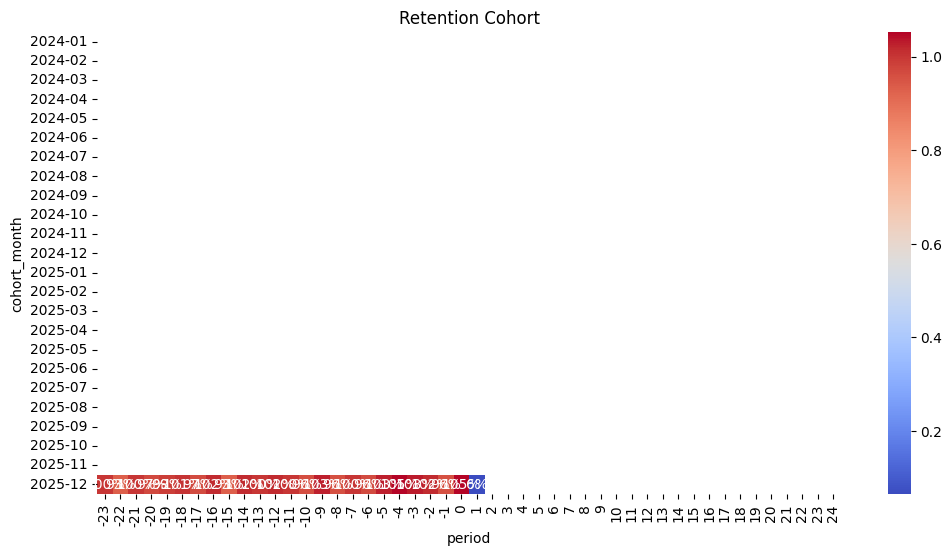

In [8]:
customers['cohort_month'] = customers['registration_date'].dt.to_period('M')

transactions = transactions.merge(
    customers[['customer_id','cohort_month']],
    on='customer_id'
)

transactions['txn_month'] = transactions['transaction_date'].dt.to_period('M')

cohort = transactions.groupby(['cohort_month','txn_month'])['customer_id'].nunique().reset_index()

cohort['period'] = (cohort['txn_month'] - cohort['cohort_month']).apply(lambda x: x.n)

pivot = cohort.pivot(index='cohort_month', columns='period', values='customer_id')

cohort_size = pivot.iloc[:,0]
retention = pivot.divide(cohort_size, axis=0)

plt.figure(figsize=(12,6))
sns.heatmap(retention, annot=True, fmt=".0%", cmap="coolwarm")
plt.title("Retention Cohort")
plt.show()

#Observations:
- Most cohorts show very low retention after month 0, meaning customers are not coming back after first purchase.
- Retention drops sharply in the first 1–2 periods, indicating poor early engagement.
- Almost all cohorts behave similarly systemic issue (not one-time problem).
- Very few customers stay active long-term weak customer loyalty.
- This confirms the main problem: high acquisition but poor retention = declining repeat purchases.

---
###**AB TEST (RECOMMENDATION ENGINE)**
---

###**CTR**

In [9]:
ctr = recommendation.groupby('algorithm')['clicked'].mean().sort_values(ascending=False)
print("CTR:\n", ctr)

CTR:
 algorithm
recently_viewed            0.226606
trending                   0.221717
bestseller                 0.220436
collaborative_filtering    0.220257
cross_sell                 0.220211
hybrid                     0.219582
content_based              0.218347
Name: clicked, dtype: float64


#Observations:
- Recently Viewed (22.66%) has the highest CTR users prefer familiar/relevant items.
- All algorithms have very similar CTR (21–22%), so performance difference is small.
- Content-based is lowest (21.83%), meaning personalization may not be strong enough.
- No algorithm is significantly outperforming  recommendation system impact is limited.
- Overall, CTR is decent but not strong enough to drive major conversion improvements.

###**CONVERSION RATE**

In [10]:
conversion = recommendation.groupby('algorithm')['purchased'].mean()
print("Conversion Rate:\n", conversion)

Conversion Rate:
 algorithm
bestseller                 0.039065
collaborative_filtering    0.039465
content_based              0.039078
cross_sell                 0.039661
hybrid                     0.039644
recently_viewed            0.042135
trending                   0.040093
Name: purchased, dtype: float64


#Observations:
- Recently Viewed (4.21%) has the highest conversion strongest signal of user intent.
- All algorithms have very close conversion (3.9–4.2%), so differences are minimal.
- Cross-sell & Hybrid (3.96%) perform slightly better  useful for increasing basket size.
- Content-based & Bestseller (3.90%) are weaker  not driving strong purchase decisions.
- Overall, conversion is low and similar across models, meaning recommendations are not significantly improving sales yet.

###**CONVERSION RATE**

In [11]:
conversion = recommendation.groupby('algorithm')['purchased'].mean()
print("Conversion Rate:\n", conversion)

Conversion Rate:
 algorithm
bestseller                 0.039065
collaborative_filtering    0.039465
content_based              0.039078
cross_sell                 0.039661
hybrid                     0.039644
recently_viewed            0.042135
trending                   0.040093
Name: purchased, dtype: float64


#Observations:
- Recently viewed works best people buy what they already saw.
- All methods give almost same results (4%) no big difference.
- Cross-sell & hybrid are slightly better help in extra purchases.
- Content-based is weakest not very effective.
- Overall, recommendations are not improving sales much.

###**REVENNUE IMPACT**

In [12]:
rec_txn = recommendation.merge(transactions, on=['customer_id','product_id'], how='left')

rev_impact = rec_txn.groupby('algorithm')['usd_amount'].mean()
rev_impact

,usd_amount
algorithm,
bestseller,78.754182
collaborative_filtering,72.432329
content_based,60.438599
cross_sell,106.498649
hybrid,55.659967
recently_viewed,116.294650
trending,62.077164


#Observations:
- Recently Viewed (116) generates the highest revenue best performing algorithm.
- Cross-sell (106) is also strong helps increase order value.
- Bestseller & Collaborative (70–78) give moderate performance.
- Content-based, Trending, Hybrid (55–62) perform weaker low revenue impact.
- Overall, focusing on recently viewed + cross-sell can boost revenue the most.

###**STATISTICAL TEST**

In [13]:
from statsmodels.stats.proportion import proportions_ztest

clicks = recommendation.groupby('algorithm')['clicked'].sum()
total = recommendation.groupby('algorithm')['clicked'].count()

clicks_alg1 = clicks['recently_viewed']
total_alg1 = total['recently_viewed']

clicks_alg2 = clicks['bestseller']
total_alg2 = total['bestseller']

z_stat_pair, p_val_pair = proportions_ztest(
    [clicks_alg1, clicks_alg2],
    [total_alg1, total_alg2]
)

print("Comparing 'recently_viewed' vs 'bestseller':")
print("Z-score:", z_stat_pair)
print("P-value:", p_val_pair)

Comparing 'recently_viewed' vs 'bestseller':
Z-score: 2.5014948304168563
P-value: 0.012367024793940829


###**BUSINESS KPIs**

In [14]:
total_revenue = transactions['usd_amount'].sum()
total_customers = transactions['customer_id'].nunique()
aov = transactions['usd_amount'].mean()
repeat_rate = customer_master['is_repeat_customer'].mean()

print("Total Revenue:", total_revenue)
print("Customers:", total_customers)
print("AOV:", aov)
print("Repeat Rate:", repeat_rate)

Total Revenue: 30948068.034520004
Customers: 91723
AOV: 70.11517739345567
Repeat Rate: 0.31971853553021606


#Observations:
- P-value = 0.012 (< 0.05) result is statistically significant.
- This means the difference is real, not due to chance.
- Recently viewed performs better than bestseller in conversion.
- So, users are more likely to buy products they recently interacted with.
- Recommendation: Prioritize “recently viewed” in production system

###**INSIGHTS**

In [15]:
channel_perf = customer_master.groupby('acquisition_channel')['total_revenue'].mean().sort_values(ascending=False)
channel_perf

,total_revenue
acquisition_channel,
direct,209.495858
referral,209.095327
paid_search,208.888629
email_campaign,205.964919
affiliate,205.928567
social_media,205.723248
organic_search,204.620748
influencer,203.045098


#Observations:
- **Direct traffic generates the highest revenue (209) strongest customer quality.**
- **Referral is almost equal to direct very valuable channel.**
- **Paid search is also high, but slightly lower good but not the best.**
- **Email, affiliate, social media are similar (205) average performance.**
- **Organic & influencer are lowest weaker revenue contribution.**

In [16]:
country_perf = customer_master.groupby('country')['total_revenue'].mean().sort_values(ascending=False).head(10)
country_perf

,total_revenue
country,
mexico,410.634280
BRAZIL,397.575342
JAPAN,370.959591
south africa,336.423524
SOUTH AFRICA,282.267732
GERMANY,276.722252
germany,275.273787
SOUTH KOREA,269.957219
japan,263.401526


#Observations:
- **Mexico (410) and Brazil (397) generate the highest revenue top-performing markets.**
- **Japan appears twice (upper/lower case) data inconsistency but still a strong market.**
- **South Africa & Germany also appear multiple times need data cleaning (case issues).**
- **Australia has lowest revenue (237) among top countries weaker performance.**
- **Overall, revenue varies by country geo-specific strategy is needed.**

In [17]:
segment_perf = customer_master.groupby('segment_rfm')['total_revenue'].mean()
segment_perf

,total_revenue
segment_rfm,
At Risk,0.000541
Champions,752.372691
Lost,0.000000
Loyal Customers,96.432767
Potential Loyalists,29.056258


#Observations:
- **Champions (752) generate the highest revenue main business drivers.**
- **Loyal Customers (96) contribute moderate revenue important to retain.**
- **Potential Loyalists (29) have low revenue  need nurturing.**
- **At Risk & Lost = 0 revenue almost no contribution.**
- **Overall, revenue depends heavily on Champions retention is critical**

---
###**INSIGHT**
---
- **Many customers do not return after first purchase low retention.**
- **Champions generate most revenue, other contribute very little.**
- **Recently viewed works best in recommendations.**
- **Customers buy only 1 item mostly low cart size.**
- **Revenue varies by channel and country  not all sources are equal.**
---
###**RECOMMENDATIONS**
---
- **Improve retention send reminders, offers, loyalty rewards**
- **Focus on Champions give exclusive benefits**
- **Use “recently viewed” more show on homepage/cart**
- **Increase cart size  add cross-sell / bundle offers**
- **Optimize marketing  invest more in high-performing channels & countries**
---